# ÉquiAlgo : rapport d'audit

**Hackathon Génie et Informatique 2026 · Défi IVADO ÉquiAlgo**

## Résumé

- Le comité accordait la bourse à 48,4 % des candidat·es des grands centres, contre 27,3 % en région éloignée. L'écart de cote R (28,0 contre 27,3) n'en explique qu'une petite partie.
- À dossier égal, venir d'une région éloignée divisait par environ 9 les cotes d'obtenir la bourse, soit l'équivalent de 1,6 point de cote R retiré.
- Le comité avantageait aussi les familles aisées. Nous n'avons trouvé aucun biais lié à la première génération universitaire.
- Retirer la colonne région ne corrige rien : le code postal et la distance trahissent la région presque parfaitement (effet proxy).
- Métrique d'équité retenue : l'égalité des chances.

## Paramètrisation

### Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

os.makedirs('figures', exist_ok=True)
pd.set_option('display.width', 160)

ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

### Chargement initial

In [5]:
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
demandes = pd.read_csv('data/donnees_demandes.csv')
demandes['groupe'] = np.where(demandes['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')
demandes['eloignee'] = (demandes['groupe'] == 'Eloignee').astype(int)
print(f'{len(demandes)} dossiers historiques')

10000 dossiers historiques


## 1. Le constat

Le comité a accordé une bourse à 40 % des candidat·es. Ce taux est-il le même partout, et les profils des deux groupes diffèrent-ils ?

In [6]:
par_region = demandes.groupby('region_administrative').agg(
    dossiers=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r_moyenne=('cote_r_equivalent', 'mean'),
).sort_values('taux_octroi')
print(par_region.round(3).to_string())
print()
print(demandes.groupby('groupe').agg(
    taux_octroi=('decision_octroi', 'mean'),
    cote_r_moyenne=('cote_r_equivalent', 'mean'),
    revenu_moyen=('revenu_familial_estime', 'mean'),
    heures_moyennes=('heures_travail_semaine', 'mean'),
    distance_moyenne=('distance_domicile_campus_km', 'mean'),
    premiere_generation=('premiere_generation_universitaire', 'mean'),
).round(2).T.to_string())

                               dossiers  taux_octroi  cote_r_moyenne
region_administrative                                               
Cote-Nord                          1178        0.263          27.325
Bas-Saint-Laurent                  1293        0.269          27.296
Gaspesie-Iles-de-la-Madeleine      1529        0.284          27.354
Montreal                           4001        0.483          27.988
Capitale-Nationale                 1999        0.484          27.984

groupe                 Centre  Eloignee
taux_octroi              0.48      0.27
cote_r_moyenne          27.99     27.33
revenu_moyen         76056.29  56330.32
heures_moyennes          8.97     13.02
distance_moyenne        19.79    221.45
premiere_generation      0.26      0.44


Les trois régions éloignées ont toutes un taux d'octroi d'environ 27 %, contre environ 48 % dans les deux grands centres. La cote R moyenne ne diffère pourtant que de 0,7 point.

Les deux groupes ont aussi des profils différents : en région éloignée, le revenu familial est plus bas, les heures de travail et la distance au campus plus élevées. Ces différences expliquent pourquoi ces variables peuvent servir de proxys de la région (section 3).

## 2. Le modèle en production et son biais

On reproduit le modèle en production (forêt aléatoire sur toutes les colonnes) et on mesure, par groupe, son exactitude, son taux de sélection et son taux de vrais positifs.

In [7]:
CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']
A_RETIRER = ['id_candidat', 'decision_octroi', 'groupe', 'eloignee']

def encoder(df_entrainement, df_cible):
    X  = pd.get_dummies(df_entrainement.drop(columns=A_RETIRER, errors='ignore'), columns=CATEGORIELLES)
    Xc = pd.get_dummies(df_cible.drop(columns=A_RETIRER, errors='ignore'), columns=CATEGORIELLES)
    return X, Xc.reindex(columns=X.columns, fill_value=0)

def mesures_par_groupe(y_vrai, y_pred, groupe):
    d = pd.DataFrame({'y': np.asarray(y_vrai), 'p': np.asarray(y_pred), 'g': np.asarray(groupe)})
    return d.groupby('g').apply(lambda t: pd.Series({
        'exactitude': (t['y'] == t['p']).mean(),
        'taux_selection': t['p'].mean(),
        'taux_vrais_positifs_vs_comite': t.loc[t['y'] == 1, 'p'].mean(),
    }))

train, test = train_test_split(demandes, test_size=0.3, random_state=42,
                               stratify=demandes['decision_octroi'])
X_train, X_test = encoder(train, test)
y_train, y_test = train['decision_octroi'], test['decision_octroi']

modele = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

tableau = mesures_par_groupe(y_test, y_pred, test['groupe'])
print(f'Exactitude globale : {accuracy_score(y_test, y_pred):.1%}\n')
print(tableau.round(3).to_string())
ecart = tableau.loc['Centre', 'taux_selection'] - tableau.loc['Eloignee', 'taux_selection']
print(f'\nÉcart de parité démographique : {ecart:.3f}')


Exactitude globale : 88.1%

          exactitude  taux_selection  taux_vrais_positifs_vs_comite
g                                                                  
Centre         0.878           0.459                          0.847
Eloignee       0.887           0.271                          0.785

Écart de parité démographique : 0.188


Le modèle atteint environ 88 % d'exactitude, mais il sélectionne beaucoup moins les candidat·es des régions éloignées (écart de parité d'environ 0,19).

**Pourquoi ces mesures ne suffisent pas.** L'exactitude et le taux de vrais positifs sont calculés contre `decision_octroi`, c'est-à-dire contre les décisions du comité que nous auditons. Une exactitude de 88 % prouve seulement que le modèle copie fidèlement le comité, biais compris. Pour savoir si une décision est juste, il faut une autre référence que le comité lui-même : c'est pourquoi nous analysons le comité à mérite comparable (section 4).

## 3. L'effet proxy : retirer la région ne suffit pas

Le réflexe est de supprimer la colonne région. On mesure ce que ça change, puis on cherche quelles variables « trahissent » la région.

In [8]:
def ecart_sans(prefixes):
    garder = [c for c in X_train.columns if not c.startswith(prefixes)] if prefixes else list(X_train.columns)
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
    m.fit(X_train[garder], y_train)
    p = m.predict(X_test[garder])
    t = pd.Series(p).groupby(test['groupe'].values).mean()
    return accuracy_score(y_test, p), t['Centre'] - t['Eloignee']

essais = {
    'Toutes les colonnes': (),
    'Sans région': ('region_administrative_',),
    'Sans région ni code postal': ('region_administrative_', 'code_postal_3_'),
    'Sans région, code postal ni distance': ('region_administrative_', 'code_postal_3_', 'distance_domicile_campus_km'),
}
resultats = pd.DataFrame([(nom, *ecart_sans(p)) for nom, p in essais.items()],
                         columns=['modele', 'exactitude', 'ecart_parite']).set_index('modele')
print(resultats.round(3).to_string())


                                      exactitude  ecart_parite
modele                                                        
Toutes les colonnes                        0.881         0.188
Sans région                                0.884         0.180
Sans région ni code postal                 0.879         0.173
Sans région, code postal ni distance       0.871         0.110


Code postal (3 caractères)    1.000
Distance domicile-campus      0.998
Heures de travail             0.805
Revenu familial               0.693
Première génération           0.590
Cote R                        0.561
Programme d'études            0.554


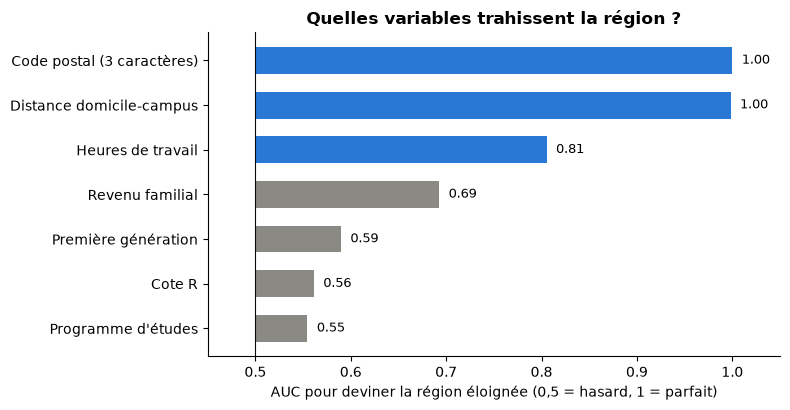

Région devinée avec toutes les autres colonnes : AUC 1.000
Région devinée avec sans le code postal : AUC 0.998


In [9]:
VARIABLES = {
    'distance_domicile_campus_km': 'Distance domicile-campus',
    'code_postal_3': 'Code postal (3 caractères)',
    'heures_travail_semaine': 'Heures de travail',
    'revenu_familial_estime': 'Revenu familial',
    'premiere_generation_universitaire': 'Première génération',
    'cote_r_equivalent': 'Cote R',
    'programme_etudes': "Programme d'études",
}

def auc_seule(col):
    # AUC obtenue en devinant la région avec cette seule variable (0,5 = hasard, 1 = parfait)
    x = demandes[col]
    if not pd.api.types.is_numeric_dtype(x):
        x = x.map(demandes.groupby(col)['eloignee'].mean())
    auc = roc_auc_score(demandes['eloignee'], x)
    return max(auc, 1 - auc)

proxys = pd.Series({nom: auc_seule(col) for col, nom in VARIABLES.items()}).sort_values()
print(proxys.sort_values(ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4.2))
couleurs = ['#2a78d6' if v >= 0.7 else '#8a8984' for v in proxys]
ax.barh(proxys.index, proxys.values - 0.5, left=0.5, color=couleurs, height=0.6)
ax.axvline(0.5, color='#0b0b0b', linewidth=0.8)
for i, v in enumerate(proxys.values):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlim(0.45, 1.05)
ax.set_xlabel('AUC pour deviner la région éloignée (0,5 = hasard, 1 = parfait)')
ax.set_title('Quelles variables trahissent la région ?', fontweight='bold')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig('figures/proxys_region.png', dpi=200, bbox_inches='tight')
plt.show()

# Toutes les autres colonnes ensemble, avec et sans le code postal
X_reg = pd.get_dummies(demandes.drop(columns=A_RETIRER + ['region_administrative']),
                       columns=['programme_etudes', 'code_postal_3'])
Xa, Xb, ya, yb = train_test_split(X_reg, demandes['eloignee'], test_size=0.3,
                                  random_state=42, stratify=demandes['eloignee'])
sans_cp = [c for c in X_reg.columns if not c.startswith('code_postal_3_')]
for nom, cols in [('toutes les autres colonnes', list(X_reg.columns)), ('sans le code postal', sans_cp)]:
    d = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
    d.fit(Xa[cols], ya)
    print(f'Région devinée avec {nom} : AUC {roc_auc_score(yb, d.predict_proba(Xb[cols])[:, 1]):.3f}')


Retirer la région ne change presque rien : l'écart de parité passe de 0,188 à 0,181, puis à 0,173 sans le code postal. La raison est visible sur le graphique : le code postal et la distance permettent à eux seuls de deviner la région presque parfaitement, et les heures de travail et le revenu en portent aussi une part. Même sans le code postal, l'ensemble des autres colonnes reconstitue la région.

C'est l'**effet proxy** : supprimer l'étiquette ne supprime pas le signal. Le modèle reporte la pénalité sur les variables qui trahissent la région. C'est pourquoi notre correction garde la région dans le modèle pour isoler sa pénalité, puis la neutralise (voir `model_corrige.ipynb`).

## 4. Le biais à mérite comparable

Pour savoir si l'écart vient du mérite ou de la région, on compare des candidat·es de cote R semblable (quartiles), puis on estime l'effet de chaque variable « toutes choses égales par ailleurs » avec une régression logistique.

In [10]:
df = demandes.copy()
df['tranche_cote_r'] = pd.qcut(df['cote_r_equivalent'], 4, labels=['Q1 faible', 'Q2', 'Q3', 'Q4 forte'])
df['tranche_revenu'] = pd.qcut(df['revenu_familial_estime'], 3, labels=['faible', 'moyen', 'élevé'])

print("Taux d'octroi du comité à cote R comparable :")
print(df.pivot_table(index='tranche_cote_r', columns='groupe', values='decision_octroi',
                     aggfunc='mean', observed=True).round(3).to_string())
print('\nRégion × première génération universitaire :')
print(df.pivot_table(index='tranche_cote_r', columns=['groupe', 'premiere_generation_universitaire'],
                     values='decision_octroi', aggfunc='mean', observed=True).round(3).to_string())
print('\nRégion × tranche de revenu :')
print(df.pivot_table(index='tranche_cote_r', columns=['groupe', 'tranche_revenu'],
                     values='decision_octroi', aggfunc='mean', observed=True).round(3).to_string())


Taux d'octroi du comité à cote R comparable :
groupe          Centre  Eloignee
tranche_cote_r                  
Q1 faible        0.013     0.003
Q2               0.200     0.055
Q3               0.636     0.342
Q4 forte         0.971     0.852

Région × première génération universitaire :
groupe                            Centre        Eloignee       
premiere_generation_universitaire      0      1        0      1
tranche_cote_r                                                 
Q1 faible                          0.010  0.019    0.003  0.002
Q2                                 0.194  0.218    0.059  0.050
Q3                                 0.648  0.602    0.332  0.354
Q4 forte                           0.968  0.978    0.859  0.845

Région × tranche de revenu :
groupe         Centre               Eloignee              
tranche_revenu faible  moyen  élevé   faible  moyen  élevé
tranche_cote_r                                            
Q1 faible       0.006  0.002  0.025    0.002  0.000  0.

In [11]:
FORMULE = ('decision_octroi ~ cote_r_equivalent + C(programme_etudes) + eloignee'
           ' + premiere_generation_universitaire + I(revenu_familial_estime / 10000)'
           ' + heures_travail_semaine + distance_domicile_campus_km')
logit = smf.logit(FORMULE, data=demandes).fit(disp=0)
b = logit.params
print(pd.DataFrame({
    'rapport_de_cotes': np.exp(b),
    'IC95_bas': np.exp(logit.conf_int()[0]),
    'IC95_haut': np.exp(logit.conf_int()[1]),
    'p_valeur': logit.pvalues,
    'equivalent_points_cote_R': b / b['cote_r_equivalent'],
}).drop(index='Intercept').round(3).to_string())

# Même régression SANS la région : les autres variables absorbent-elles la pénalité ?
logit_sans = smf.logit(FORMULE.replace(' + eloignee', ''), data=demandes).fit(disp=0)
print('\nRapports de cotes avec et sans la variable région :')
print(pd.DataFrame({'avec_region': np.exp(logit.params),
                    'sans_region': np.exp(logit_sans.params)}).drop(index='Intercept').round(3).to_string())


                                          rapport_de_cotes  IC95_bas  IC95_haut  p_valeur  equivalent_points_cote_R
C(programme_etudes)[T.Genie]                         1.070     0.859      1.332     0.547                     0.049
C(programme_etudes)[T.Sante]                         1.084     0.857      1.372     0.502                     0.059
C(programme_etudes)[T.Sciences]                      1.042     0.832      1.303     0.721                     0.030
C(programme_etudes)[T.Sciences sociales]             1.012     0.808      1.267     0.918                     0.009
cote_r_equivalent                                    3.962     3.736      4.203     0.000                     1.000
eloignee                                             0.109     0.083      0.145     0.000                    -1.608
premiere_generation_universitaire                    0.955     0.823      1.109     0.548                    -0.033
I(revenu_familial_estime / 10000)                    1.265     1.234    

**À cote R comparable, l'écart reste massif.** Au troisième quartile de cote R, le comité accordait la bourse à 63 % des candidat·es des centres, contre 34 % en région éloignée. Même parmi les meilleur·es (quatrième quartile), environ 97 % contre 85 %.

**La régression chiffre la pénalité.** Comment lire le rapport de cotes : 1 = aucun effet ; sous 1, la variable réduit les chances ; au-dessus de 1, elle les augmente.

| Variable | Rapport de cotes | Équivalent en cote R | Verdict |
| --- | --- | --- | --- |
| Région éloignée | 0,109 | −1,6 point | Biais : plus du double de l'écart réel de cote R (0,7 point) |
| Revenu familial (par 10 000 $) | 1,265 | +0,17 point | Biais : avantage aux familles aisées, indéfendable pour une bourse d'excellence |
| Heures de travail (par heure) | 1,220 | +0,14 point | Légitime : valorise la persévérance |
| Cote R (par point) | 3,962 | référence | Mérite scolaire |
| Première génération | 0,955 (p = 0,55) | négligeable | Aucun biais détecté |
| Programme d'études | 1,01 à 1,08 (p > 0,5) | négligeable | Aucun effet |
| Distance (par km) | 1,001 | négligeable | Pas d'effet propre une fois la région prise en compte |

**Pas de biais lié à la première génération**, ni seul ni combiné avec la région : les colonnes 0 et 1 du deuxième tableau sont presque identiques. C'est un résultat négatif que nous rapportons volontairement.

**Le revenu est un second biais**, présent dans les deux groupes : à cote R égale, les familles à revenu élevé obtiennent nettement plus souvent la bourse. Comme le revenu est plus bas en région, ce biais aggrave aussi l'écart régional.

**Le dernier tableau montre l'effet proxy dans la régression elle-même** : sans la variable région, les coefficients des variables liées à la région changent, parce qu'elles absorbent une partie de la pénalité.


## 5. Choix de la métrique d'équité : l'égalité des chances

Deux définitions s'affrontent, et elles ne peuvent pas être satisfaites en même temps quand les deux groupes n'ont pas le même profil :

- **Parité démographique** : le même taux d'octroi dans les deux groupes, quels que soient les dossiers.
- **Égalité des chances** : parmi les candidat·es qui méritent la bourse, la même probabilité de l'obtenir, quelle que soit la région.

Nous retenons l'**égalité des chances** :

1. **Elle respecte les écarts légitimes.** La cote R moyenne est un peu plus basse en région. La parité forcerait à ignorer cette différence réelle ; l'égalité des chances interdit seulement de refuser un bon dossier à cause de sa région.
2. **Elle correspond à la mission d'une bourse d'excellence** : récompenser le mérite, à mérite égal sans égard à l'origine.
3. **Elle est défendable devant les personnes refusées** : chacune peut vérifier qu'un dossier identique au sien, venu d'ailleurs, aurait reçu la même décision.

**Limite :** mesurer l'égalité des chances exige de savoir qui mérite la bourse. Les décisions du comité ne peuvent pas servir de référence, puisque ce sont elles qu'on audite. Nous utilisons donc deux mesures indirectes : le taux d'octroi à cote R comparable et le F1 de HxBuddy, calculé contre l'étalon indépendant.

## 6. Synthèse : quelles variables garder ?

| Variable | Porte la région ? | Légitime pour une bourse d'excellence ? | Traitement dans notre solution |
| --- | --- | --- | --- |
| Région | c'est la variable sensible | Non | Gardée pour isoler sa pénalité, puis neutralisée |
| Code postal | Oui, presque parfaitement | Non | Exclu de la grille |
| Distance | Oui, presque parfaitement | Non | Gardée, effet propre négligeable |
| Revenu familial | En partie | Non (biais à part entière) | Neutralisé (tout le monde au revenu médian) |
| Heures de travail | En partie | Oui (persévérance) | Gardées |
| Cote R | Faiblement | Oui (mérite) | Gardée |
| Programme, première génération | Faiblement | Neutres | Gardés, sans effet |

## 7. Plan de surveillance en production

Objectif : détecter le retour d'un biais avant qu'il touche les candidat·es, et garder la grille explicable et contestable.

### 7.1 Indicateurs suivis

| Indicateur | Ce qu'il mesure | Seuil d'alerte proposé | Fréquence |
| --- | --- | --- | --- |
| Taux d'octroi global | Respect de l'enveloppe | Hors de 37 % à 43 % (marge avant les bornes 36-44 %) | Chaque cohorte |
| Écart de taux d'octroi Centre − Éloignée | Parité entre régions | Écart supérieur à 5 points, dans un sens ou dans l'autre | Chaque cohorte |
| Écart à cote R comparable | Traitement égal à mérite égal | Écart supérieur à 10 points dans un quartile de cote R | Chaque cohorte |
| Égalité des chances (taux de vrais positifs par groupe) | Notre métrique principale | Écart supérieur à 0,05 | Une fois par an, sur l'échantillon audité (7.3) |
| Stabilité de la grille | Poids de la cote R et des heures de travail | Variation de plus de 20 % d'un coefficient | Une fois par an |
| Dérive des données | Profil des nouveaux dossiers (cote R, revenu, heures, régions) | Indice de stabilité de population (PSI) supérieur à 0,25 sur une variable | Chaque cohorte |
| Proxys | Capacité des variables gardées à deviner la région | Hausse nette par rapport à l'audit initial | Une fois par an |
| Contestations | Demandes d'explication et de révision | Hausse marquée, ou révisions concentrées dans une région | Chaque trimestre |

### 7.2 Rôles

| Rôle | Responsabilité |
| --- | --- |
| Propriétaire du modèle (direction des bourses) | Approuve la grille, reçoit les alertes, décide d'une suspension |
| Équipe science des données | Calcule les indicateurs, enquête sur les alertes, propose les corrections |
| Comité d'éthique indépendant | Valide le choix de la métrique et des seuils, revoit l'échantillon audité |
| Responsable de la protection des renseignements personnels | Veille au respect de la Loi 25 (information et révision des décisions) |

### 7.3 Une référence indépendante, chaque année

On ne peut pas mesurer l'égalité des chances contre les décisions du modèle lui-même. Chaque année, un comité indépendant évalue à l'aveugle un échantillon de dossiers (par exemple 300, répartis entre les régions), **sans voir la région, le code postal ni le revenu**. Ses décisions servent de référence pour calculer l'écart d'égalité des chances.

### 7.4 Procédure en cas d'alerte

1. **Signaler** : l'équipe de données avise le propriétaire du modèle dans les 48 heures.
2. **Analyser** : décomposer l'écart par variable pour trouver sa cause (dérive des données, nouveau proxy, changement de profil des candidat·es).
3. **Protéger les candidat·es** : si l'alerte touche l'équité, les dossiers proches du seuil de décision passent en révision humaine en attendant la correction.
4. **Corriger** : réestimer la grille, la faire valider par le comité d'éthique, documenter le changement.
5. **Rendre compte** : consigner l'alerte, la cause et la correction dans un registre consultable par le comité d'éthique.

### 7.5 Droits des candidat·es (Loi 25)

La décision étant fondée sur un traitement automatisé, chaque candidat·e est informé·e que la décision a été rendue ainsi. Sur demande, on lui communique les renseignements utilisés et les principaux facteurs de la décision (sa cote R et ses heures de travail ; ni sa région ni le revenu familial), et la personne peut présenter ses observations à un membre du personnel en mesure de réviser la décision.

### 7.6 Ce qu'on s'interdit

- **Réentraîner la grille sur ses propres décisions.** Le modèle apprendrait de lui-même et figerait ses erreurs (boucle de rétroaction). On réestime seulement sur des décisions auditées.
- **Réintroduire la région, le code postal ou le revenu** comme critères de décision.
- **Changer la grille sans validation** du comité d'éthique et sans trace dans le registre.
